In [2]:
!pip install -q langchain-huggingface langchain-qdrant sentence-transformers numpy pandas langchain_community


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.4/390.4 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [7]:
import json, time
from pathlib import Path

import numpy as np
import pandas as pd
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore
from sentence_transformers import CrossEncoder
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

In [8]:
# ── Credentials ───────────────────────────────────────────────
QDRANT_URL     = ""
QDRANT_API_KEY = ""

# ── Fixed embedding model
EMBED_MODEL      = "abhinand/MedEmbed-base-v0.1"
COLLECTION_NAME  = "ada_model_medembed_base_v0.1"

# ── Retrieval / reranking knobs ────────────────────────────────
RETRIEVE_K = 20
RERANK_TOP  = 5

# ── Reranker models to compare ────────────────────────────────
RERANKERS = {
    "ms-marco-MiniLM-L6-v2": "cross-encoder/ms-marco-MiniLM-L6-v2",
    "bge-reranker-base":      "BAAI/bge-reranker-base",
    "bge-reranker-v2-m3":    "BAAI/bge-reranker-v2-m3",
}

In [9]:
# ── Eval dataset ──────────────────────────────────────────────
EVAL_PATH = Path("/content/eval_queries_multi_chunk.json")
with open(EVAL_PATH) as f:
    eval_queries = json.load(f)

print(f"Loaded {len(eval_queries)} queries from {EVAL_PATH.name}")
print(f"Embedding : {EMBED_MODEL}")
print(f"Collection: {COLLECTION_NAME}")


Loaded 30 queries from eval_queries_multi_chunk.json
Embedding : abhinand/MedEmbed-base-v0.1
Collection: ada_model_medembed_base_v0.1


Metrics

In [10]:
def precision_at_k(retrieved: list, relevant: list, k: int = 5) -> float:
    return len(set(retrieved[:k]) & set(relevant)) / k

def recall_at_k(retrieved: list, relevant: list, k: int = 10) -> float:
    if not relevant:
        return 0.0
    return len(set(retrieved[:k]) & set(relevant)) / len(relevant)

def mrr(retrieved: list, relevant: list) -> float:
    rel_set = set(relevant)
    for i, cid in enumerate(retrieved, 1):
        if cid in rel_set:
            return 1.0 / i
    return 0.0

def ndcg_at_k(retrieved: list, scores: dict, k: int = 5) -> float:
    dcg  = sum(scores.get(cid, 0) / np.log2(i + 1)
               for i, cid in enumerate(retrieved[:k], 1))
    idcg = sum(s / np.log2(i + 1)
               for i, s in enumerate(sorted(scores.values(), reverse=True)[:k], 1))
    return dcg / idcg if idcg > 0 else 0.0

def hit_at_k(retrieved: list, relevant: list, k: int = 5) -> float:
    return 1.0 if set(retrieved[:k]) & set(relevant) else 0.0

In [13]:
embeddings = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

vector_store = QdrantVectorStore.from_existing_collection(
    collection_name=COLLECTION_NAME,
    embedding=embeddings,
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
)


In [15]:
#Setting up the retriever
retriever = vector_store.as_retriever(search_kwargs={"k": RETRIEVE_K})


In [16]:
def evaluate_reranker(reranker_name: str, reranker_model_path: str) -> dict:
    """
    Run the full eval loop for one CrossEncoder reranker.

    Pipeline per query:
      retriever.invoke(query)          → RETRIEVE_K docs from Qdrant
      cross_encoder.rank(query, docs)  → sorted by score
      top RERANK_TOP ids               → metrics
    Latency covers the entire pipeline (retrieval + reranking).
    """
    print(f"Reranker : {reranker_name}")
    print(f"Model    : {reranker_model_path}")

    cross_encoder = CrossEncoder(reranker_model_path)

    p5_list, r10_list, mrr_list, ndcg5_list, hit5_list, lat_list = [], [], [], [], [], []

    for i, item in enumerate(eval_queries, 1):
        query        = item["query"]
        relevant_ids = item["ground_truth"]["relevant_chunk_ids"]
        rel_scores   = item["ground_truth"]["relevance_scores"]

        # ── Step 1: Vector retrieval ───────────────────────────
        t0   = time.time()
        docs = retriever.invoke(query)

        # ── Step 2: CrossEncoder reranking ────────────────────
        passages     = [doc.page_content for doc in docs]
        ce_inputs    = [[query, p] for p in passages]
        ce_scores    = cross_encoder.predict(ce_inputs)

        # Sort docs by descending CE score
        ranked_docs  = sorted(zip(ce_scores, docs), key=lambda x: x[0], reverse=True)
        top_docs     = [doc for _, doc in ranked_docs[:RERANK_TOP]]
        lat          = time.time() - t0

        # ── Step 3: Extract chunk IDs ──────────────────────────
        retrieved_ids = [doc.metadata.get("chunk_id") for doc in top_docs]
        # For recall we use the full reranked list (up to 10)
        all_reranked  = [doc.metadata.get("chunk_id") for _, doc in ranked_docs]

        p5    = precision_at_k(retrieved_ids, relevant_ids, k=5)
        r10   = recall_at_k(all_reranked,     relevant_ids, k=10)
        mrr_s = mrr(retrieved_ids,             relevant_ids)
        ndcg5 = ndcg_at_k(retrieved_ids,       rel_scores,  k=5)
        hit5  = hit_at_k(retrieved_ids,         relevant_ids, k=5)

        p5_list.append(p5);  r10_list.append(r10);  mrr_list.append(mrr_s)
        ndcg5_list.append(ndcg5);  hit5_list.append(hit5);  lat_list.append(lat)

        print(f"  [{i:02d}] P@5={p5:.2f} NDCG@5={ndcg5:.2f} Hit@5={int(hit5)} | "
              f"{lat*1000:.0f}ms | {query[:50]}…")

    result = {
        "Reranker":    reranker_name,
        "Precision@5": round(float(np.mean(p5_list)),   3),
        "Recall@10":   round(float(np.mean(r10_list)),  3),
        "MRR":         round(float(np.mean(mrr_list)),  3),
        "NDCG@5":      round(float(np.mean(ndcg5_list)),3),
        "Hit@5":       round(float(np.mean(hit5_list)), 3),
        "Latency_ms":  round(float(np.mean(lat_list)) * 1000, 1),
    }

    print(f"\n  Precision@5 : {result['Precision@5']}")
    print(f"  Recall@10   : {result['Recall@10']}")
    print(f"  MRR         : {result['MRR']}")
    print(f"  NDCG@5      : {result['NDCG@5']}")
    print(f"  Hit@5       : {result['Hit@5']}")
    print(f"  Latency     : {result['Latency_ms']} ms")

    return result

Evaluation

In [ ]:
all_results = []

for name, path in RERANKERS.items():
    result = evaluate_reranker(name, path)
    all_results.append(result)

Final comparison

In [24]:
baseline = {
    "Reranker":    "MedEmbed-only (Baseline)",
    "Precision@5": 0.393,
    "Recall@10":   0.562,
    "MRR":         0.797,
    "NDCG@5":      0.511,
    "Hit@5":       0.867,
    "Latency_ms":  249.8,
}

df = (pd.DataFrame([baseline] + all_results)
        .sort_values("NDCG@5", ascending=False)
        .reset_index(drop=True))

print("\n" + "="*75)
print("RERANKER EVALUATION — sorted by NDCG@5")
print(f"Base retrieval: MedEmbed top-{RETRIEVE_K} → CrossEncoder → top-{RERANK_TOP}")
print("="*75)
print(df.to_string(index=False))


RERANKER EVALUATION — sorted by NDCG@5
Base retrieval: MedEmbed top-20 → CrossEncoder → top-5
                Reranker  Precision@5  Recall@10   MRR  NDCG@5  Hit@5  Latency_ms
MedEmbed-only (Baseline)        0.393      0.562 0.797   0.511  0.867       249.8
      bge-reranker-v2-m3        0.393      0.584 0.788   0.497  0.900      1611.7
       bge-reranker-base        0.407      0.580 0.765   0.493  0.900       821.0
   ms-marco-MiniLM-L6-v2        0.307      0.434 0.553   0.360  0.767       354.7


In [27]:
#save to CSV
csv_path = "/content/reranker_evaluation_results.csv"
df.to_csv(csv_path, index=False)

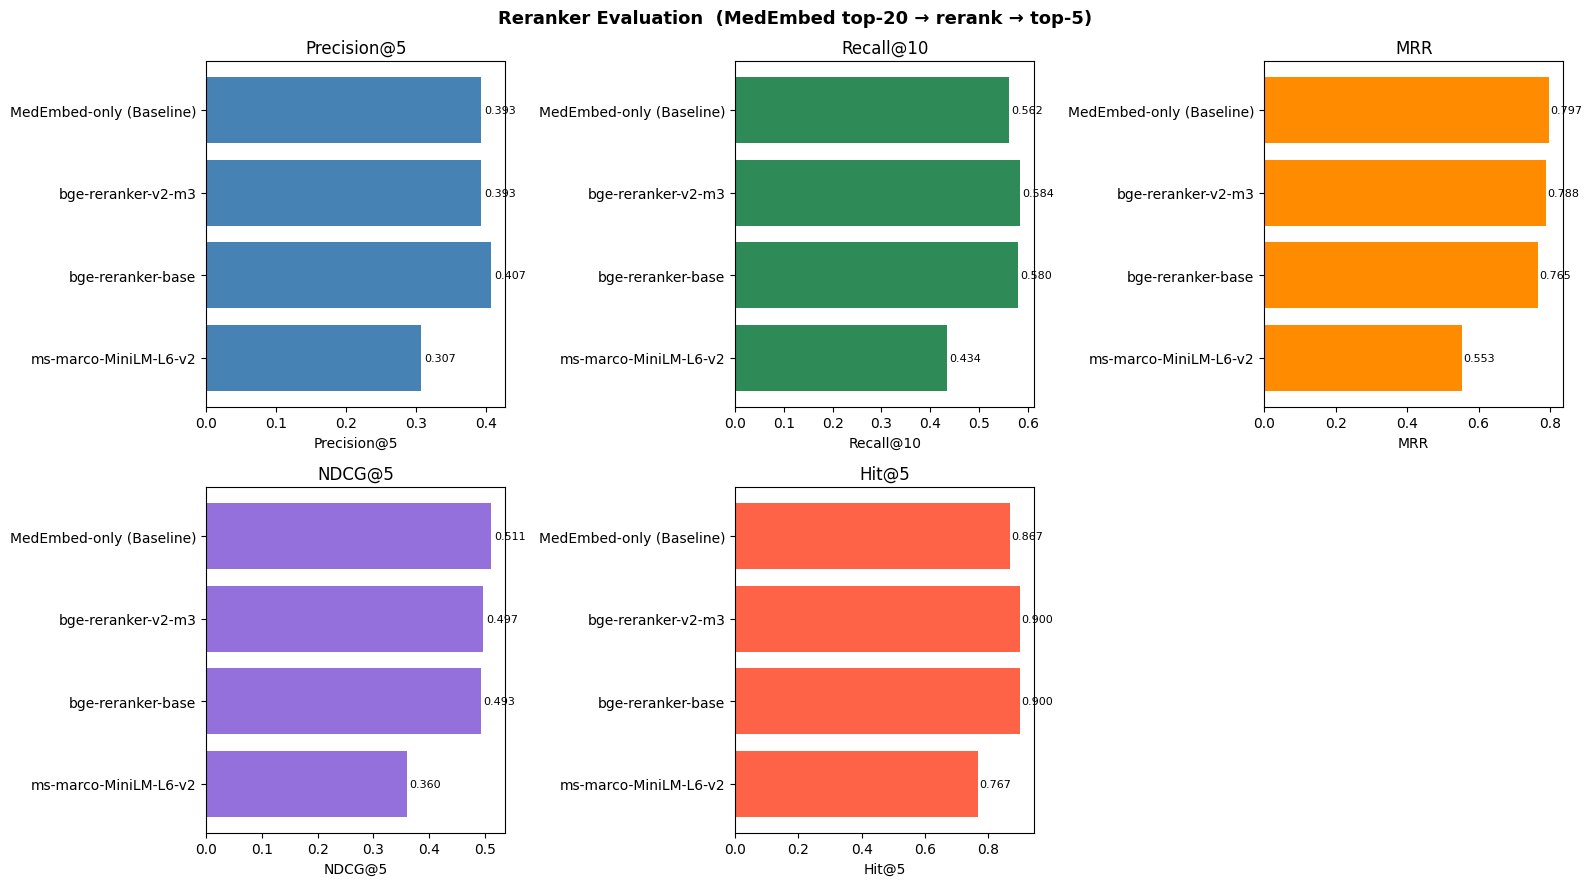

In [26]:
import matplotlib.pyplot as plt

metrics = ["Precision@5", "Recall@10", "MRR", "NDCG@5", "Hit@5"]
colors  = ["steelblue", "seagreen", "darkorange", "mediumpurple", "tomato"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, metric, color in zip(axes, metrics, colors):
    ax.barh(df["Reranker"], df[metric], color=color)
    ax.set_xlabel(metric)
    ax.set_title(metric)
    ax.invert_yaxis()
    for j, v in enumerate(df[metric]):
        ax.text(v + 0.005, j, f"{v:.3f}", va="center", fontsize=8)

axes[-1].axis("off")  # hide unused 6th panel
plt.suptitle(
    f"Reranker Evaluation  (MedEmbed top-{RETRIEVE_K} → rerank → top-{RERANK_TOP})",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/content/reranker_evaluation_charts.png", dpi=150, bbox_inches="tight")
plt.show()